In [1]:
from pathlib import Path
from typing import Any
import h5py


In [8]:


def print_h5_structure(file_path: Path) -> None:
    """
    Print the hierarchical structure of an HDF5 file.
    """

    def print_item(name: str, obj: Any) -> None:
        indent: str = "  " * name.count("/")
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}📦 Dataset: {name}")
            print(f"{indent}   ├─ shape: {obj.shape}")
            print(f"{indent}   ├─ dtype: {obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}📂 Group: {name}")

    with h5py.File(file_path, "r") as f:
        print(f"\n🔎 Inspecting: {file_path}\n")
        f.visititems(print_item)

folder = Path(r"C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\outputs\Urban-1\raw")

h5_files = list(folder.rglob("*.h5"))[:4]
# print(h5_files)
for f in h5_files:
    print_h5_structure(f)


🔎 Inspecting: C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\outputs\Urban-1\raw\Case01_buildings-h2048-L100-N25_062157-S25_060358-E121_498476-W121_496487_rho1.03_out1.0.h5

📦 Dataset: static_mask
   ├─ shape: (2, 256, 539)
   ├─ dtype: float32
📦 Dataset: turbulence
   ├─ shape: (0, 9, 256, 539)
   ├─ dtype: float32

🔎 Inspecting: C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\outputs\Urban-1\raw\Case02_buildings-h2048-L143-N25_062302-S25_060504-E121_544418-W121_542427_rho1.001_out1.0.h5

📦 Dataset: static_mask
   ├─ shape: (2, 256, 539)
   ├─ dtype: float32
📦 Dataset: turbulence
   ├─ shape: (0, 9, 256, 539)
   ├─ dtype: float32

🔎 Inspecting: C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\outputs\Urban-1\raw\Case03_buildings-h2048-L145-N25_065847-S25_064048-E121_499397-W121_497407_rho1.01_out1.0.h5

📦 Dataset: mean_vel_field
   ├─ shape: (9, 256, 539)
   ├─ dtype: float32
📦 Dataset: mean_vel_sq_field
   ├─ shape: (256, 539)
   ├─ dtype: float32
📦 Dataset: static_mask
   ├─ shape: (2, 2

Step 1 - Read image: 0.0704s
Step 2 - Threshold: 0.0009s
Step 3 - Connected components: 0.0051s
Found 27 connected components (excluding background)
Step 4 - Extract contours: 0.2007s
Step 5 - Compute minimum distance: 0.4101s
Minimum distance: 2.00 pixels between labels 2 and 5
Step 6 - Colorize components: 0.0501s


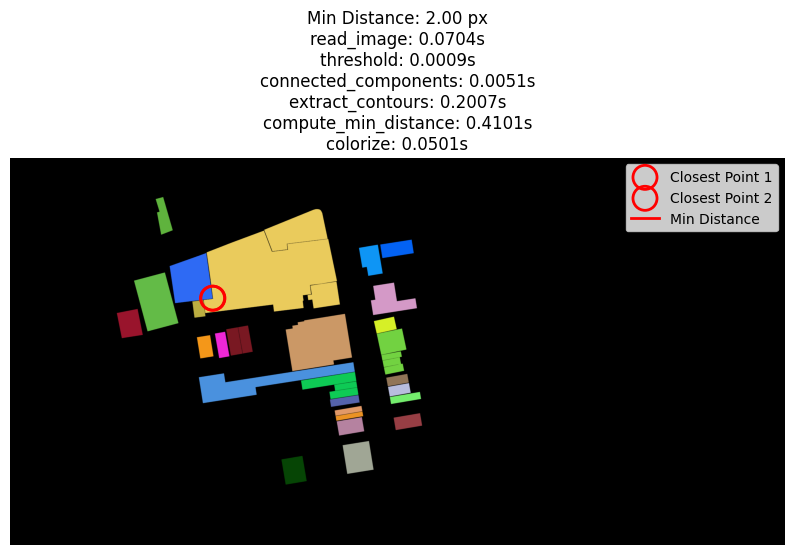

Step 7 - Plot: 0.2083s
Total elapsed time: 0.9455s
Step 1 - Read image: 0.0695s
Step 2 - Threshold: 0.0011s
Step 3 - Connected components: 0.0049s
Found 19 connected components (excluding background)
Step 4 - Extract contours: 0.1501s
Step 5 - Compute minimum distance: 0.4226s
Minimum distance: 2.00 pixels between labels 7 and 9
Step 6 - Colorize components: 0.0508s


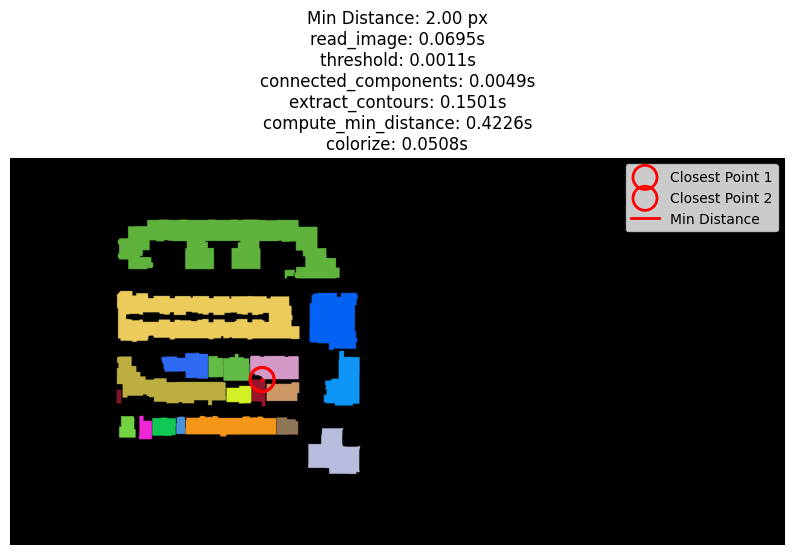

Step 7 - Plot: 0.2061s
Total elapsed time: 0.9051s
Step 1 - Read image: 0.0873s
Step 2 - Threshold: 0.0010s
Step 3 - Connected components: 0.0047s
Found 21 connected components (excluding background)
Step 4 - Extract contours: 0.1307s
Step 5 - Compute minimum distance: 0.5676s
Minimum distance: 2.83 pixels between labels 17 and 20
Step 6 - Colorize components: 0.0506s


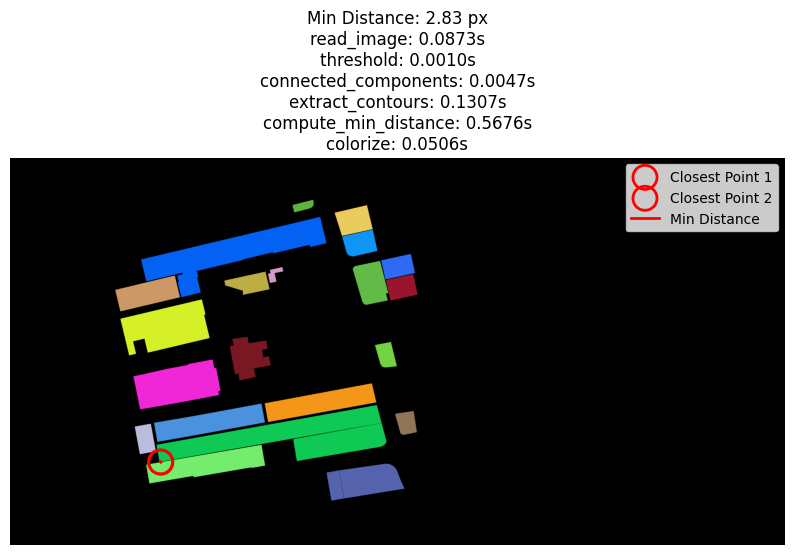

Step 7 - Plot: 0.2028s
Total elapsed time: 1.0446s
Step 1 - Read image: 0.0576s
Step 2 - Threshold: 0.0009s
Step 3 - Connected components: 0.0043s
Found 16 connected components (excluding background)
Step 4 - Extract contours: 0.0951s
Step 5 - Compute minimum distance: 0.1742s
Minimum distance: 8.54 pixels between labels 3 and 5
Step 6 - Colorize components: 0.0532s


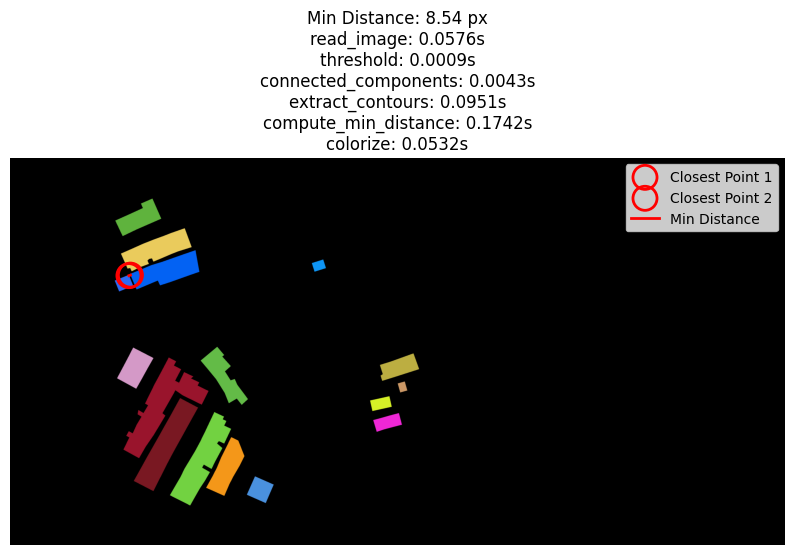

Step 7 - Plot: 0.2032s
Total elapsed time: 0.5885s


In [14]:
import cv2
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import time
from itertools import combinations
from pathlib import Path



img_path = r"C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\SimCases\Urban-1\masks\buildings-h2048-L17-N25_024863-S25_023065-E121_573318-W121_571328.png"

folder = Path(r"C:\Users\User\Desktop\NCA_workspace\01-lbm-2d\SimCases\Urban-1\masks")

img_files = list(folder.rglob("*.png"))[:4]

def min_img(img_path):
    # -------------------------------
    # 1️⃣ 讀取圖片
    start = time.time()
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    timings = {}
    timings['read_image'] = time.time() - start
    print(f"Step 1 - Read image: {timings['read_image']:.4f}s")

    # -------------------------------
    # 2️⃣ 門檻化
    start = time.time()
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    timings['threshold'] = time.time() - start
    print(f"Step 2 - Threshold: {timings['threshold']:.4f}s")

    # -------------------------------
    # 3️⃣ 標記連通區塊
    start = time.time()
    num_labels, labels = cv2.connectedComponents(binary)
    timings['connected_components'] = time.time() - start
    print(f"Step 3 - Connected components: {timings['connected_components']:.4f}s")
    print(f"Found {num_labels-1} connected components (excluding background)")

    # -------------------------------
    # 4️⃣ 取得每個區塊的輪廓
    start = time.time()
    contours_list = []
    for i in range(1, num_labels):
        mask = (labels == i).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours_list.append(contours[0][:,0,:])  # (N,2) numpy array
    timings['extract_contours'] = time.time() - start
    print(f"Step 4 - Extract contours: {timings['extract_contours']:.4f}s")

    # -------------------------------
    # 5️⃣ 計算最接近的兩個區塊
    start = time.time()
    min_dist = np.inf
    closest_pair = (None, None)
    closest_points = (None, None)

    for i,j in combinations(range(len(contours_list)),2):
        coords1 = contours_list[i]
        coords2 = contours_list[j]
        dist_matrix = cdist(coords1, coords2)
        local_min_idx = np.unravel_index(dist_matrix.argmin(), dist_matrix.shape)
        local_min = dist_matrix[local_min_idx]
        if local_min < min_dist:
            min_dist = local_min
            closest_pair = (i+1,j+1)  # +1 因為 labels 從 1 開始
            closest_points = (coords1[local_min_idx[0]], coords2[local_min_idx[1]])
    timings['compute_min_distance'] = time.time() - start
    print(f"Step 5 - Compute minimum distance: {timings['compute_min_distance']:.4f}s")
    print(f"Minimum distance: {min_dist:.2f} pixels between labels {closest_pair[0]} and {closest_pair[1]}")

    # -------------------------------
    # 6️⃣ 彩色顯示每個區塊
    start = time.time()
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0,0,0]  # 背景黑色
    colored_img = colors[labels]
    timings['colorize'] = time.time() - start
    print(f"Step 6 - Colorize components: {timings['colorize']:.4f}s")

    # -------------------------------
    # 7️⃣ 繪圖 + 標記最近距離
    start = time.time()
    plt.figure(figsize=(10,10))
    plt.imshow(colored_img)
    p1, p2 = closest_points
    plt.scatter(p1[0], p1[1], s=300, edgecolors='red', facecolors='none', linewidths=2, label='Closest Point 1')
    plt.scatter(p2[0], p2[1], s=300, edgecolors='red', facecolors='none', linewidths=2, label='Closest Point 2')
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], c='red', linewidth=2, label='Min Distance')

    # 將每個步驟耗時加到圖標題
    title_text = f"Min Distance: {min_dist:.2f} px\n" + "\n".join([f"{k}: {v:.4f}s" for k,v in timings.items()])
    plt.title(title_text)
    plt.axis('off')
    plt.legend()
    plt.show()
    timings['plot'] = time.time() - start
    print(f"Step 7 - Plot: {timings['plot']:.4f}s")

    # -------------------------------
    # 8️⃣ 總耗時
    total_time = sum(timings.values())
    print(f"Total elapsed time: {total_time:.4f}s")


for i in img_files:
    min_img(i)